4.1 :

recording...
done.
playing...
done.


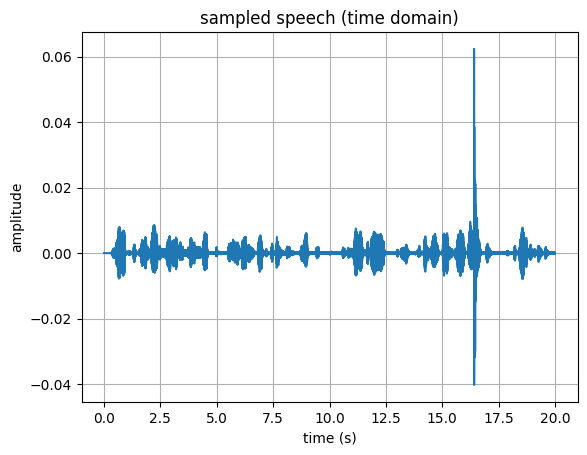

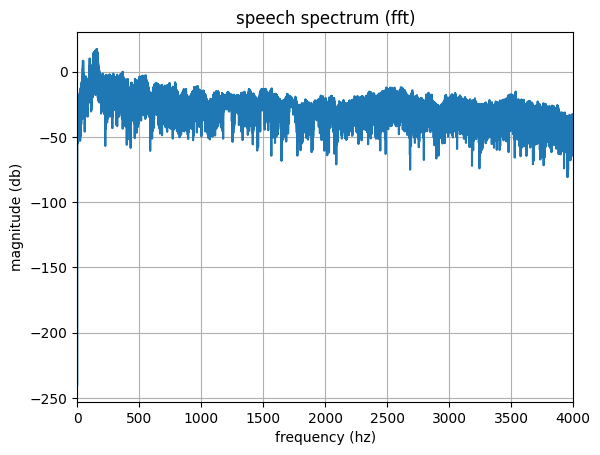

fs = 8000 hz, duration = 20 s, samples = 160000
energy ratio in 300-3400 hz: 0.075


In [7]:
# 4.1 audio sampling

import numpy as np
import matplotlib.pyplot as plt

# audio i/o
try:
    import sounddevice as sd
except Exception as e:
    raise ImportError("install sounddevice: pip install sounddevice") from e

# params
fs = 8000          # hz
dur = 20           # s
channels = 1       # mono

# record
print("recording...")
x = sd.rec(int(dur * fs), samplerate=fs, channels=channels, dtype=np.float32)
sd.wait()
x = x.reshape(-1)  # flatten
print("done.")

# listen
print("playing...")
sd.play(x, fs)
sd.wait()
print("done.")

# time axis
t = np.arange(len(x)) / fs

# time plot
plt.figure()
plt.plot(t, x)
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("sampled speech (time domain)")
plt.grid(True)
plt.show()

# fft
n = len(x)
w = np.hanning(n)          # window
xw = x * w                 # windowed
xw = xw - np.mean(xw)      # dc remove

xf = np.fft.rfft(xw)
f = np.fft.rfftfreq(n, d=1/fs)

mag = np.abs(xf)
mag_db = 20 * np.log10(mag + 1e-12)   # db

# spectrum plot
plt.figure()
plt.plot(f, mag_db)
plt.xlim(0, 4000)          # speech band view
plt.xlabel("frequency (hz)")
plt.ylabel("magnitude (db)")
plt.title("speech spectrum (fft)")
plt.grid(True)
plt.show()

# band check
band_lo = 300
band_hi = 3400
mask = (f >= band_lo) & (f <= band_hi)

p_tot = np.sum(mag**2)
p_band = np.sum(mag[mask]**2)
ratio = p_band / (p_tot + 1e-15)

print(f"fs = {fs} hz, duration = {dur} s, samples = {n}")
print(f"energy ratio in {band_lo}-{band_hi} hz: {ratio:.3f}")


4.2)

4.2 results
fs = 8000 hz
nb = 8 bits/sample
bit rate r = fs*nb = 64000 bps = 64.0 kbps
quant range = [-0.0403, 0.0623]
delta = 0.000402
snr (quantization) = 23.78 db
pcm bitstream length = 1280000 bits


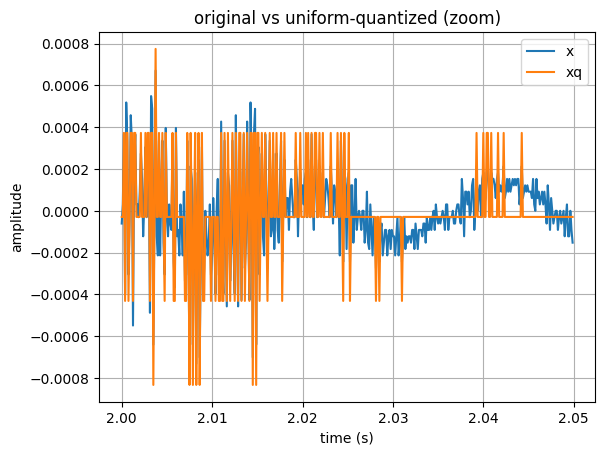

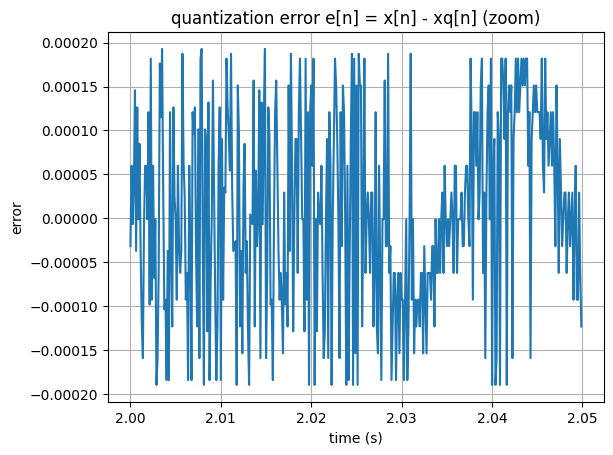

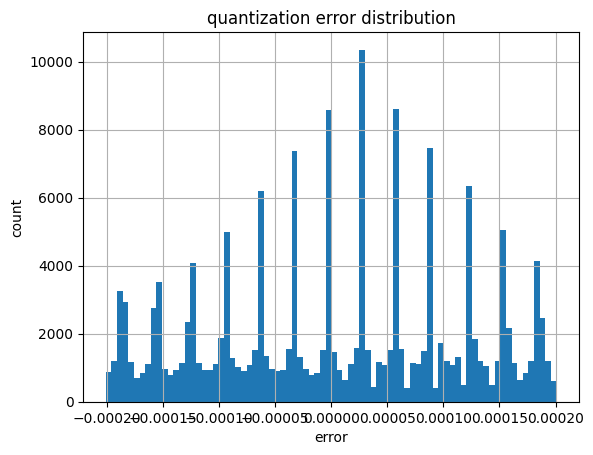

In [8]:
# 4.2 uniform quantization + pcm

import numpy as np
import matplotlib.pyplot as plt

# required vars
if "x" not in globals() or "fs" not in globals():
    raise NameError("run 4.1 first so x and fs exist")

# params
nb = 8                 # bits
l = 2 ** nb            # levels

def uniformquantizer(x_in, nb=8):
    # range
    xmin = float(np.min(x_in))
    xmax = float(np.max(x_in))
    if np.isclose(xmax, xmin):
        return x_in.copy(), np.zeros_like(x_in, dtype=np.int32), {
            "xmin": xmin, "xmax": xmax, "delta": 0.0, "levels": 2**nb
        }

    # step
    levels = 2 ** nb
    delta = (xmax - xmin) / (levels - 1)

    # index
    k = np.round((x_in - xmin) / delta).astype(np.int32)
    k = np.clip(k, 0, levels - 1)

    # reconstruct
    xq = xmin + k * delta
    meta = {"xmin": xmin, "xmax": xmax, "delta": float(delta), "levels": levels}
    return xq.astype(np.float32), k, meta

def indices_to_bits(k, nb=8):
    # pack bits
    k = k.astype(np.uint16)
    bits = ((k[:, None] >> np.arange(nb - 1, -1, -1)) & 1).astype(np.uint8)
    return bits.reshape(-1)

# quantize
xq, k, meta = uniformquantizer(x, nb=nb)

# error
e = x - xq

# snr
px = np.mean(x ** 2)
pe = np.mean(e ** 2) + 1e-15
snr_db = 10 * np.log10(px / pe)

# pcm rate
r_bps = int(fs * nb)

print("4.2 results")
print(f"fs = {fs} hz")
print(f"nb = {nb} bits/sample")
print(f"bit rate r = fs*nb = {r_bps} bps = {r_bps/1000:.1f} kbps")
print(f"quant range = [{meta['xmin']:.4f}, {meta['xmax']:.4f}]")
print(f"delta = {meta['delta']:.6f}")
print(f"snr (quantization) = {snr_db:.2f} db")

# pcm bits
bits_pcm = indices_to_bits(k, nb=nb)
print(f"pcm bitstream length = {len(bits_pcm)} bits")

# time axis
t = np.arange(len(x)) / fs

# zoom window
t0 = 2.0
tw = 0.05
i0 = int(t0 * fs)
i1 = int((t0 + tw) * fs)

# waveform compare
plt.figure()
plt.plot(t[i0:i1], x[i0:i1], label="x")
plt.plot(t[i0:i1], xq[i0:i1], label="xq")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("original vs uniform-quantized (zoom)")
plt.grid(True)
plt.legend()
plt.show()

# error plot
plt.figure()
plt.plot(t[i0:i1], e[i0:i1])
plt.xlabel("time (s)")
plt.ylabel("error")
plt.title("quantization error e[n] = x[n] - xq[n] (zoom)")
plt.grid(True)
plt.show()

# error histogram
plt.figure()
plt.hist(e, bins=80)
plt.xlabel("error")
plt.ylabel("count")
plt.title("quantization error distribution")
plt.grid(True)
plt.show()


4.3 )

4.3 mu-law results
fs = 8000 hz
bits = 8
mu = 255.0
snr (mu-law) = 37.41 db
snr (uniform) = 23.78 db


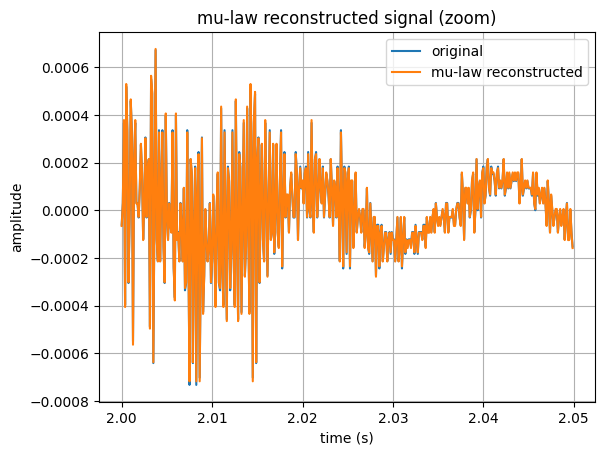

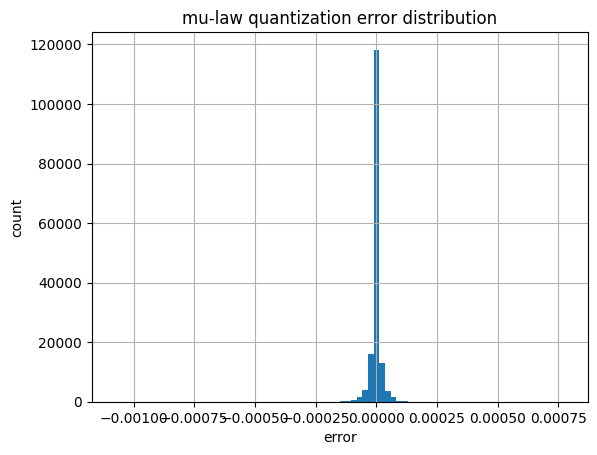

In [9]:
# 4.3 miu-law

import numpy as np
import matplotlib.pyplot as plt

# safety
if "x" not in globals() or "fs" not in globals():
    raise NameError("run 4.1 first so x and fs exist")

# params
nb = 8
levels = 2 ** nb
mu = 255.0

# normalize
xmax = np.max(np.abs(x))
xn = x / (xmax + 1e-15)

# mu-law compressor
def compressor_mu(xn, mu=255.0):
    return np.sign(xn) * np.log1p(mu * np.abs(xn)) / np.log1p(mu)

# mu-law expander
def expander_mu(y, mu=255.0):
    return np.sign(y) * (1 / mu) * ((1 + mu) ** np.abs(y) - 1)

# compress
yc = compressor_mu(xn, mu)

# uniform quantization (compressed domain)
delta = 2 / (levels - 1)
k = np.round((yc + 1) / delta)
k = np.clip(k, 0, levels - 1)
yq = -1 + k * delta

# expand
xhat = expander_mu(yq, mu) * xmax

# error
e_mu = x - xhat

# snr
px = np.mean(x ** 2)
pe_mu = np.mean(e_mu ** 2) + 1e-15
snr_mu_db = 10 * np.log10(px / pe_mu)

print("4.3 mu-law results")
print(f"fs = {fs} hz")
print(f"bits = {nb}")
print(f"mu = {mu}")
print(f"snr (mu-law) = {snr_mu_db:.2f} db")

# comparison with uniform quantization (from 4.2)
if "xq" in globals():
    e_u = x - xq
    pe_u = np.mean(e_u ** 2) + 1e-15
    snr_u_db = 10 * np.log10(px / pe_u)
    print(f"snr (uniform) = {snr_u_db:.2f} db")

# time axis
t = np.arange(len(x)) / fs

# zoom
t0 = 2.0
tw = 0.05
i0 = int(t0 * fs)
i1 = int((t0 + tw) * fs)

# waveform compare
plt.figure()
plt.plot(t[i0:i1], x[i0:i1], label="original")
plt.plot(t[i0:i1], xhat[i0:i1], label="mu-law reconstructed")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("mu-law reconstructed signal (zoom)")
plt.grid(True)
plt.legend()
plt.show()

# error histogram
plt.figure()
plt.hist(e_mu, bins=80)
plt.xlabel("error")
plt.ylabel("count")
plt.title("mu-law quantization error distribution")
plt.grid(True)
plt.show()


4.4.3 )

In [13]:
# 4.4 part 3 listening quality comparison

import sounddevice as sd
import numpy as np

# checks
for v in ["x", "xq", "xhat", "fs"]:
    if v not in globals():
        raise NameError(f"{v} not found, run previous sections first")

# normalize for playback safety
def norm_audio(y):
    m = np.max(np.abs(y)) + 1e-15
    return y / m

x_play   = norm_audio(x)
xq_play  = norm_audio(xq)
xmu_play = norm_audio(xhat)

print("playing original")
sd.play(x_play, fs)
sd.wait()

print("playing uniform quantized")
sd.play(xq_play, fs)
sd.wait()

print("playing mu-law reconstructed")
sd.play(xmu_play, fs)
sd.wait()

print("done")


# save audio files

import os
import numpy as np
from scipy.io import wavfile

# normalize helper
def norm_audio(y):
    m = np.max(np.abs(y)) + 1e-15
    return y / m

# target folder (windows path)
base_path = r"C:\Users\Asus\OneDrive\Desktop\CS_Project_402101339\voices"
os.makedirs(base_path, exist_ok=True)

# file paths
f_orig = os.path.join(base_path, "speech_original.wav")
f_uni  = os.path.join(base_path, "speech_uniform.wav")
f_mu   = os.path.join(base_path, "speech_mulaw.wav")

# float -> int16 pcm
def to_int16(y):
    y = norm_audio(y)
    return np.int16(y * 32767)

# write wav files
wavfile.write(f_orig, fs, to_int16(x))
wavfile.write(f_uni,  fs, to_int16(xq))
wavfile.write(f_mu,   fs, to_int16(xhat))

print("saved to:")
print(f_orig)
print(f_uni)
print(f_mu)



playing original
playing uniform quantized
playing mu-law reconstructed
done
saved to:
C:\Users\Asus\OneDrive\Desktop\CS_Project_402101339\voices\speech_original.wav
C:\Users\Asus\OneDrive\Desktop\CS_Project_402101339\voices\speech_uniform.wav
C:\Users\Asus\OneDrive\Desktop\CS_Project_402101339\voices\speech_mulaw.wav


5.2 )

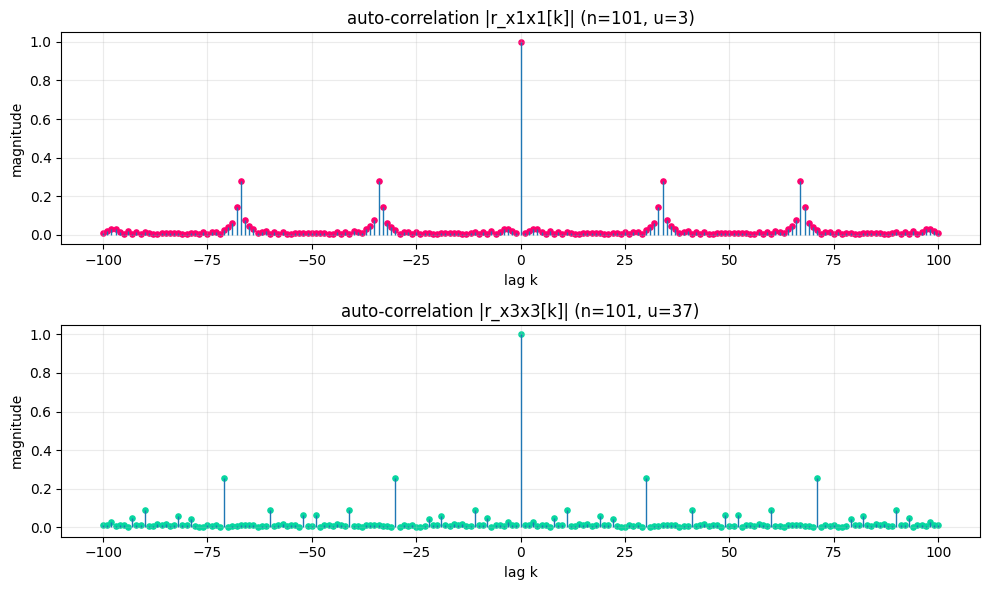

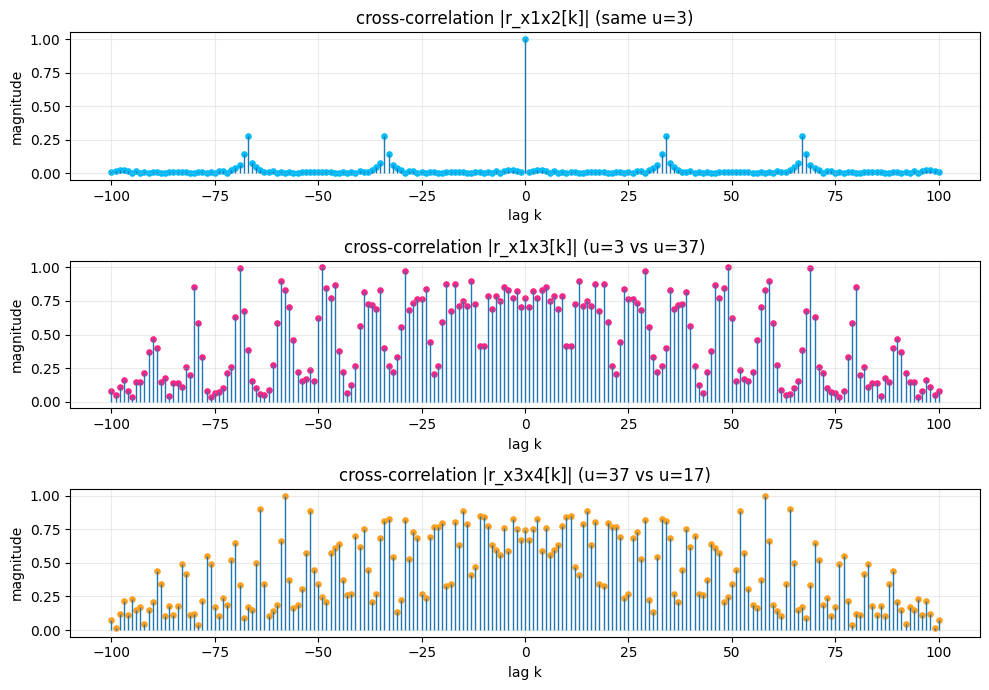

saved: fig_52_autocorr.png
saved: fig_52_crosscorr.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# zc sequence
def zc_seq(n_len: int, u_root: int) -> np.ndarray:
    # input check
    if n_len <= 0:
        raise value_error("n must be positive")
    if np.gcd(n_len, u_root) != 1:
        raise value_error("u must be coprime with n")

    n = np.arange(n_len, dtype=float)
    if n_len % 2 == 1:
        x = np.exp(-1j * np.pi * u_root * n * (n + 1.0) / n_len)
    else:
        x = np.exp(-1j * np.pi * u_root * n * n / n_len)
    return x


def cross_correlation(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # full corr
    x = np.asarray(x, dtype=complex)
    y = np.asarray(y, dtype=complex)
    return np.correlate(x, y, mode="full")


def auto_correlation(x: np.ndarray) -> np.ndarray:
    # self corr
    return cross_correlation(x, x)


# plotting helpers
def _lags(n_len: int) -> np.ndarray:
    # lag axis
    return np.arange(-(n_len - 1), n_len)


def stem_like(ax, lags, vals, title, xlabel="lag k", ylabel="magnitude"):
    # stem style
    ax.vlines(lags, 0.0, vals, linewidth=1.0)
    ax.scatter(lags, vals, s=14)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)


if __name__ == "__main__":
    # params
    n_len = 101
    u1 = 3
    u2 = 37

    # sequences
    x1 = zc_seq(n_len, u1)
    x2 = zc_seq(n_len, u1)  # same params
    x3 = zc_seq(n_len, u2)  # diff root
    x4 = zc_seq(n_len, 17)  # another root

    # correlations
    r11 = auto_correlation(x1)
    r33 = auto_correlation(x3)
    r12 = cross_correlation(x1, x2)
    r13 = cross_correlation(x1, x3)
    r34 = cross_correlation(x3, x4)

    # magnitudes
    m_r11 = np.abs(r11)
    m_r33 = np.abs(r33)
    m_r12 = np.abs(r12)
    m_r13 = np.abs(r13)
    m_r34 = np.abs(r34)

    # normalize
    eps = 1e-12
    m_r11n = m_r11 / (m_r11.max() + eps)
    m_r33n = m_r33 / (m_r33.max() + eps)
    m_r12n = m_r12 / (m_r12.max() + eps)
    m_r13n = m_r13 / (m_r13.max() + eps)
    m_r34n = m_r34 / (m_r34.max() + eps)

    # lag axis
    l = _lags(n_len)

    # figure 1: autocorrs
    fig1 = plt.figure(figsize=(10, 6))
    ax1 = fig1.add_subplot(2, 1, 1)
    ax2 = fig1.add_subplot(2, 1, 2)

    # we add some here
    ax1.set_prop_cycle(color=["#ff006e", "#3a86ff", "#8338ec"])
    stem_like(ax1, l, m_r11n, f"auto-correlation |r_x1x1[k]| (n={n_len}, u={u1})")
    ax2.set_prop_cycle(color=["#06d6a0", "#ffbe0b", "#fb5607"])
    stem_like(ax2, l, m_r33n, f"auto-correlation |r_x3x3[k]| (n={n_len}, u={u2})")

    fig1.tight_layout()
    fig1.savefig("fig_52_autocorr.png", dpi=200)

    # figure 2: crosscorrs
    fig2 = plt.figure(figsize=(10, 7))
    bx1 = fig2.add_subplot(3, 1, 1)
    bx2 = fig2.add_subplot(3, 1, 2)
    bx3 = fig2.add_subplot(3, 1, 3)

    bx1.set_prop_cycle(color=["#00bbf9", "#f15bb5", "#00f5d4"])
    stem_like(bx1, l, m_r12n, f"cross-correlation |r_x1x2[k]| (same u={u1})")

    bx2.set_prop_cycle(color=["#f72585", "#b5179e", "#7209b7"])
    stem_like(bx2, l, m_r13n, f"cross-correlation |r_x1x3[k]| (u={u1} vs u={u2})")

    bx3.set_prop_cycle(color=["#ff9f1c", "#2ec4b6", "#e71d36"])
    stem_like(bx3, l, m_r34n, f"cross-correlation |r_x3x4[k]| (u={u2} vs u=17)")

    fig2.tight_layout()
    fig2.savefig("fig_52_crosscorr.png", dpi=200)

    # optional: quick display
    plt.show()

    # quick prints
    print("saved: fig_52_autocorr.png")
    print("saved: fig_52_crosscorr.png")


5.3 )

REQ.1 )

In [6]:
import numpy as np

def make_bits_with_mib(n_total=1000, mib_len=24, mib_pos=400, seed=123):
    rng = np.random.default_rng(seed)

    bits = rng.integers(0, 2, size=n_total, dtype=np.int8)  # random bits

    mib = np.array(
        [1,0,1,1, 0,1,0,0, 1,1,0,1, 0,0,1,0, 1,0,0,1, 1,1,0,0],
        dtype=np.int8
    )  # mib pattern

    if mib.shape[0] != mib_len:
        raise ValueError("mib_len mismatch")

    if not (0 <= mib_pos <= n_total - mib_len):
        raise ValueError("mib_pos out of range")

    bits[mib_pos:mib_pos + mib_len] = mib  # insert mib

    return bits, mib, mib_pos

def main():
    n_total = 1000
    mib_len = 24

    mib_pos = 455 # change position
    seed = 121    # change randomness

    bits_1000, mib_pattern, true_pos = make_bits_with_mib(
        n_total=n_total,
        mib_len=mib_len,
        mib_pos=mib_pos,
        seed=seed
    )

    print("total bits:", bits_1000.size)
    print("mib length:", mib_pattern.size)
    print("mib position:", true_pos)
    print("mib bits:", "".join(mib_pattern.astype(str)))
    print("segment check:", "".join(bits_1000[true_pos:true_pos + mib_len].astype(str)))

if __name__ == "__main__":
    main()




total bits: 1000
mib length: 24
mib position: 455
mib bits: 101101001101001010011100
segment check: 101101001101001010011100


QPSK ( becuz im doing this in another notebook , i repeat QPSK modulation block here ) :

In [7]:
import numpy as np

def PulseShaping(bits, pulse_map, fs=1e6, tb=10e-3):
    bits = np.asarray(bits).astype(int).ravel()
    ns = int(round(fs * tb))
    y = np.zeros(len(bits) * ns, dtype=float)

    for k, b in enumerate(bits):
        p = pulse_map(b) if callable(pulse_map) else pulse_map[b]
        p = np.asarray(p, dtype=float)

        if len(p) < ns:
            p = np.pad(p, (0, ns - len(p)))
        elif len(p) > ns:
            p = p[:ns]

        y[k * ns:(k + 1) * ns] = p

    t = np.arange(len(y)) / fs
    return t, y

def qpsk_tx(bits01, fs=1e6, tb=10e-3, fc=10e3):
    bits01 = np.asarray(bits01).astype(int).ravel()
    if bits01.size % 2 != 0:
        bits01 = np.append(bits01, 0)

    b0 = bits01[0::2]
    b1 = bits01[1::2]

    i_sym = np.where((b0 == 0) & (b1 == 0),  1, 0)
    i_sym = np.where((b0 == 0) & (b1 == 1), -1, i_sym)
    i_sym = np.where((b0 == 1) & (b1 == 1), -1, i_sym)
    i_sym = np.where((b0 == 1) & (b1 == 0),  1, i_sym)

    q_sym = np.where((b0 == 0) & (b1 == 0),  1, 0)
    q_sym = np.where((b0 == 0) & (b1 == 1),  1, q_sym)
    q_sym = np.where((b0 == 1) & (b1 == 1), -1, q_sym)
    q_sym = np.where((b0 == 1) & (b1 == 0), -1, q_sym)

    ns = int(round(fs * tb))
    pulse = np.ones(ns, dtype=float)

    pulse_map = {-1: -pulse, 1: pulse}

    t_bb, y_i = PulseShaping(i_sym, pulse_map, fs=fs, tb=tb)
    _,   y_q = PulseShaping(q_sym, pulse_map, fs=fs, tb=tb)

    y_bb = y_i + 1j * y_q
    t = np.arange(len(y_bb)) / fs

    i = np.real(y_bb)
    q = np.imag(y_bb)
    xc = i * np.cos(2 * np.pi * fc * t) - q * np.sin(2 * np.pi * fc * t)

    sym = i_sym.astype(float) + 1j * q_sym.astype(float)
    return t, xc, t_bb, y_bb, sym


In [8]:
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

def channel_ideal(x, length_km=0.83, att_db_per_km=0.2):
    x = np.asarray(x)
    gain = 10 ** (-(att_db_per_km * float(length_km)) / 20.0)
    return gain * x  # gain

def add_awgn(x, noise_var=60.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x)
    n = np.sqrt(float(noise_var)) * rng.standard_normal(size=x.shape)
    return x + n  # noise

def run_5_3_2_qpsk_channel(bits_1000, fs=1e6, tb=10e-3, fc=10e3, bw=1e3,
                          sigma2=60.0, length_km=0.83, att_db_per_km=0.2, seed=123,
                          n_sym_view=8, save_figs=True, fig_prefix="fig_5_3_2"):

    if "qpsk_tx" not in globals() or not callable(globals()["qpsk_tx"]):
        raise NameError("qpsk_tx is not defined. run your previous qpsk_tx cell first.")
    if "analog_demod" not in globals() or not callable(globals()["analog_demod"]):
        raise NameError("analog_demod is not defined. run your previous analog_demod cell first.")

    t, xc_tx, t_bb, y_bb, sym = qpsk_tx(bits_1000, fs=fs, tb=tb, fc=fc)  # qpsk tx

    x_ch = channel_ideal(xc_tx, length_km=length_km, att_db_per_km=att_db_per_km)  # channel
    rng = np.random.default_rng(seed)
    r = add_awgn(x_ch, noise_var=float(sigma2), rng=rng)  # awgn

    t_rx, y_i, y_q = analog_demod(r, fs=fs, bw=bw, fc=fc)  # rx iq

    ns = int(round(fs * tb))  # sps
    n = int(n_sym_view * ns)
    n = min(n, len(xc_tx), len(r), len(y_i), len(y_q))
    if n < 10:
        raise ValueError("plot length too small. increase n_sym_view or check fs/tb.")

    t_view = np.arange(n) / fs

    fig1 = plt.figure()
    plt.plot(t_view, np.asarray(xc_tx)[:n], label="tx")
    plt.plot(t_view, np.asarray(r)[:n], label="rx")
    plt.xlabel("time (s)")
    plt.ylabel("amplitude")
    plt.title("5.3.2 passband qpsk tx and rx")
    plt.legend()
    plt.tight_layout()

    fig2 = plt.figure()
    plt.plot(t_view, np.asarray(y_i)[:n], label="y_i")
    plt.plot(t_view, np.asarray(y_q)[:n], label="y_q")
    plt.xlabel("time (s)")
    plt.ylabel("amplitude")
    plt.title("5.3.2 recovered baseband i and q")
    plt.legend()
    plt.tight_layout()

    if save_figs:
        f1 = f"{fig_prefix}_passband_tx_rx.png"
        f2 = f"{fig_prefix}_recovered_iq.png"
        fig1.savefig(f1, dpi=200, bbox_inches="tight")
        fig2.savefig(f2, dpi=200, bbox_inches="tight")
        print("saved:", f1)
        print("saved:", f2)

    plt.show()

    return {
        "t": t,
        "xc_tx": xc_tx,
        "x_ch": x_ch,
        "r": r,
        "t_bb": t_bb,
        "y_bb": y_bb,
        "sym": sym,
        "t_rx": t_rx,
        "y_i": y_i,
        "y_q": y_q,
        "params": {
            "fs": fs, "tb": tb, "fc": fc, "bw": bw,
            "sigma2": float(sigma2),
            "length_km": float(length_km),
            "att_db_per_km": float(att_db_per_km),
            "seed": int(seed),
            "n_sym_view": int(n_sym_view),
        }
    }

def main_5_3_2(bits_1000):
    out = run_5_3_2_qpsk_channel(bits_1000, sigma2=60.0, seed=123)  # run
    print("qpsk symbols:", out["sym"].size)
    print("tx samples:", len(out["xc_tx"]))
    print("sigma2:", out["params"]["sigma2"])
    return out


In [9]:
import numpy as np

def AnalogDemod(xc, fs, BW, fc, num_taps=399):
    xc = np.asarray(xc)
    t = np.arange(len(xc)) / fs

    mixI = 2.0 * xc * np.cos(2 * np.pi * fc * t)
    mixQ = -2.0 * xc * np.sin(2 * np.pi * fc * t)

    cutoff = min(BW, 0.499 * fs)
    n = np.arange(num_taps) - (num_taps - 1) / 2
    h = 2 * cutoff / fs * np.sinc(2 * cutoff * n / fs)
    h *= np.hamming(num_taps)
    h /= np.sum(h)

    yI = np.convolve(mixI, h, mode="same")
    yQ = np.convolve(mixQ, h, mode="same")

    return t, yI, yQ

def analog_demod(xc, fs, bw, fc, num_taps=399):
    return AnalogDemod(xc, fs=fs, BW=bw, fc=fc, num_taps=num_taps)



saved: fig_5_3_2_passband_tx_rx.png
saved: fig_5_3_2_recovered_iq.png


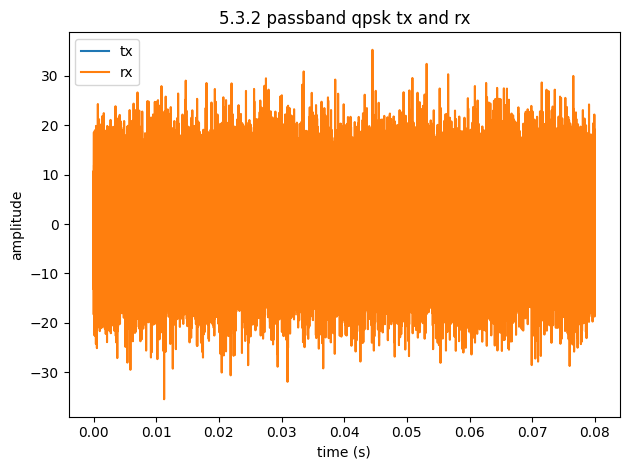

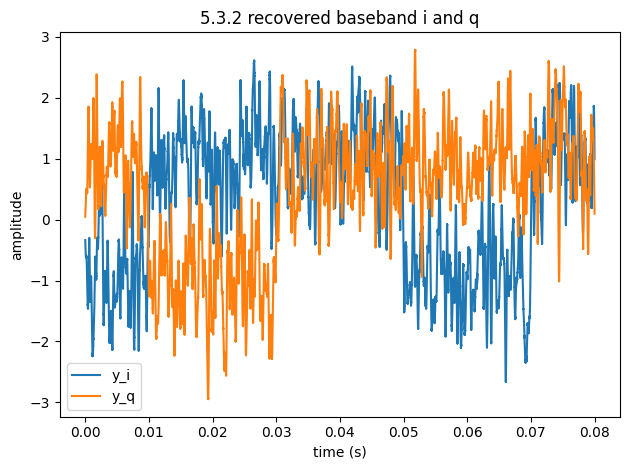

qpsk symbols: 500
tx samples: 5000000
sigma2: 60.0


In [10]:
rng = np.random.default_rng(123)
bits_1000 = rng.integers(0, 2, size=1000)
mib = np.array([1,0,1,1,0,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,1,1,0,0])


out = main_5_3_2(bits_1000)



5.3.3 )

estimated mib position (bit index): 366


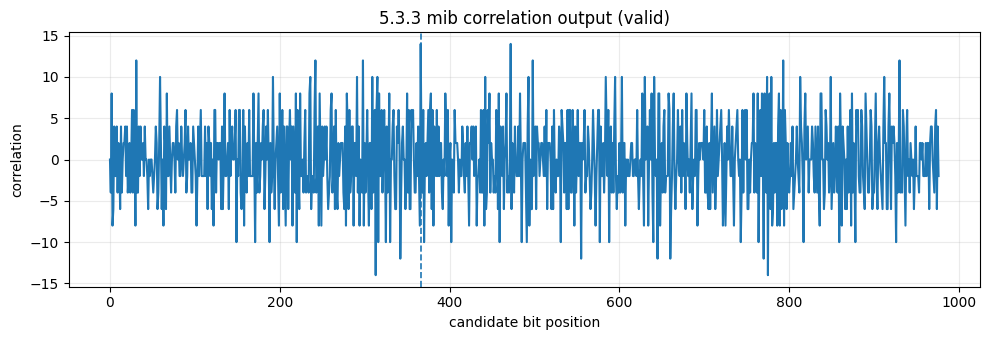

In [12]:

import numpy as np
import matplotlib.pyplot as plt

if "out" not in globals():
    raise NameError("out not defined. run: out = main_5_3_2(bits_1000)")
if "mib" not in globals():
    raise NameError("mib not defined. define your 24-bit mib array first.")

fs = float(out["params"]["fs"])
tb = float(out["params"]["tb"])
ns = int(round(fs * tb))

y_i = np.asarray(out["y_i"]).ravel()
y_q = np.asarray(out["y_q"]).ravel()

k = len(y_i) // ns
if k <= 0:
    raise ValueError("signal too short for given fs/tb")

idx = (np.arange(k) * ns + ns // 2).astype(int)
idx = idx[idx < len(y_i)]

i_s = y_i[idx]
q_s = y_q[idx]

b0 = (q_s < 0).astype(np.int8)
b1 = (i_s < 0).astype(np.int8)

bits_hat = np.empty(2 * len(b0), dtype=np.int8)
bits_hat[0::2] = b0
bits_hat[1::2] = b1

n_search = min(1000, len(bits_hat))
bits_hat_1000 = bits_hat[:n_search]

x = 2 * bits_hat_1000.astype(int) - 1
p = 2 * np.asarray(mib).astype(int).ravel() - 1

corr_mib = np.correlate(x, p, mode="valid")
mib_pos_hat = int(np.argmax(corr_mib))

print("estimated mib position (bit index):", mib_pos_hat)

plt.figure(figsize=(10, 3.5))
plt.plot(corr_mib)
plt.axvline(mib_pos_hat, linestyle="--", linewidth=1.2)
plt.title("5.3.3 mib correlation output (valid)")
plt.xlabel("candidate bit position")
plt.ylabel("correlation")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


5.3.4)

In [13]:

import numpy as np

if "zc_seq" not in globals() or not callable(globals()["zc_seq"]):
    raise NameError("zc_seq not defined. run your 5.2 zc_seq code first.")
if "out" not in globals():
    raise NameError("out not defined. run: out = main_5_3_2(bits_1000)")

sigma2 = float(out["params"]["sigma2"])

n_zc = 101
u_list = [u for u in range(1, n_zc) if np.gcd(u, n_zc) == 1]
if len(u_list) < 64:
    raise ValueError("pick a prime n_zc like 101/127/257 so you get >=64 roots")

u_list = u_list[:64]

rng = np.random.default_rng(123)
tx_idx = int(rng.integers(0, 64))
u_tx = int(u_list[tx_idx])

zc_tx = zc_seq(n_zc, u_tx)

gain = 10 ** (-(0.2 * 0.83) / 20.0)
noise = np.sqrt(sigma2 / 2.0) * (rng.standard_normal(n_zc) + 1j * rng.standard_normal(n_zc))
zc_rx = gain * zc_tx + noise

print("tx zc index (0..63):", tx_idx)
print("tx root u:", u_tx)


tx zc index (0..63): 0
tx root u: 1


5.3.5 )

In [14]:

import numpy as np

if "zc_tx" not in globals() or "zc_rx" not in globals():
    raise NameError("run 5.3.4 cell first (it defines zc_tx and zc_rx).")
if "zc_seq" not in globals() or not callable(globals()["zc_seq"]):
    raise NameError("zc_seq not defined.")
if "u_list" not in globals():
    raise NameError("u_list not defined. run 5.3.4 first.")

n_zc = len(zc_tx)
zc_bank = [zc_seq(n_zc, int(u)) for u in u_list]

peaks = np.zeros(64)
for i in range(64):
    c = np.correlate(zc_rx, zc_bank[i], mode="full")
    peaks[i] = np.max(np.abs(c))

idx_hat = int(np.argmax(peaks))

bits6 = np.array([(idx_hat >> k) & 1 for k in range(5, -1, -1)], dtype=np.int8)

print("detected zc index (0..63):", idx_hat)
print("6-bit id bits:", "".join(bits6.astype(str)))


detected zc index (0..63): 63
6-bit id bits: 111111


5.3.6)

In [15]:

import numpy as np

if "qpsk_tx" not in globals() or not callable(globals()["qpsk_tx"]):
    raise NameError("qpsk_tx not defined. run your qpsk tx code first.")
if "out" not in globals():
    raise NameError("out not defined.")
if "bits6" not in globals():
    raise NameError("bits6 not defined. run 5.3.5 first.")
if "tx_idx" not in globals() or "idx_hat" not in globals():
    raise NameError("tx_idx / idx_hat missing. run 5.3.4 and 5.3.5 first.")

fs = float(out["params"]["fs"])
tb = float(out["params"]["tb"])
fc = float(out["params"]["fc"])

t6, xc6, tbb6, ybb6, sym6 = qpsk_tx(bits6, fs=fs, tb=tb, fc=fc)

if idx_hat == tx_idx:
    print("Attach Completed")
else:
    print("Attach Failed")


Attach Failed


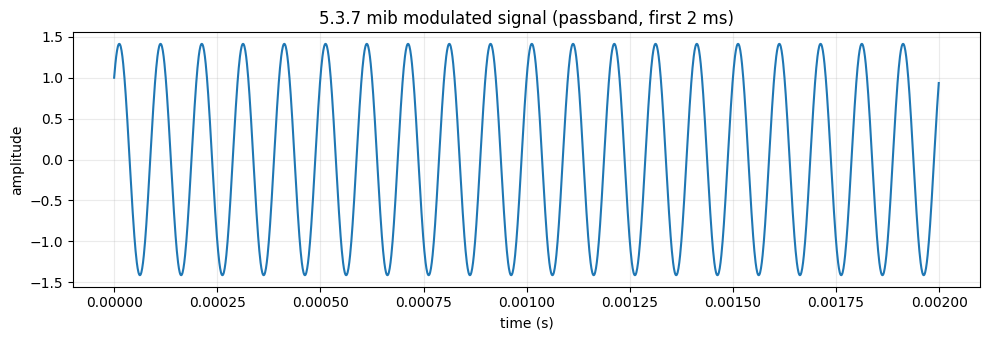

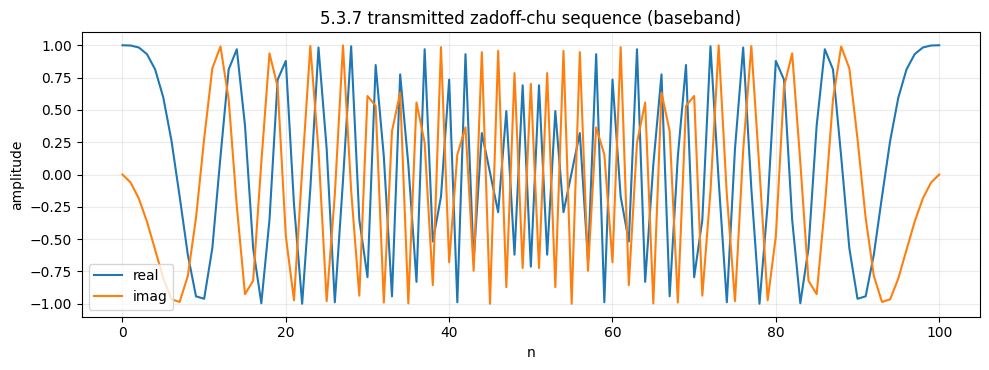

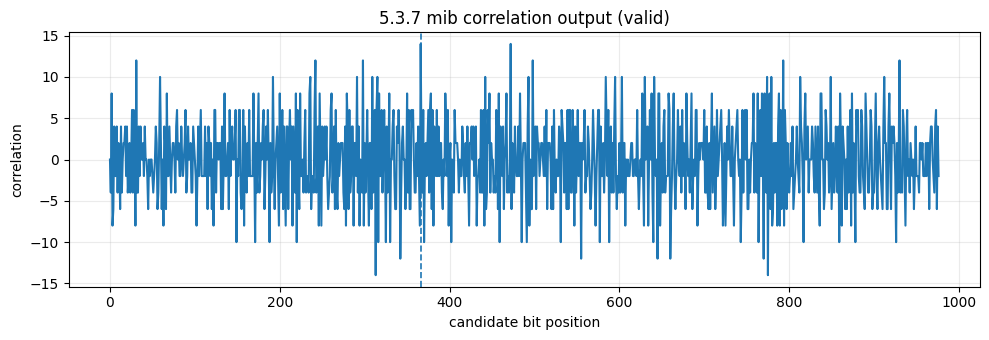

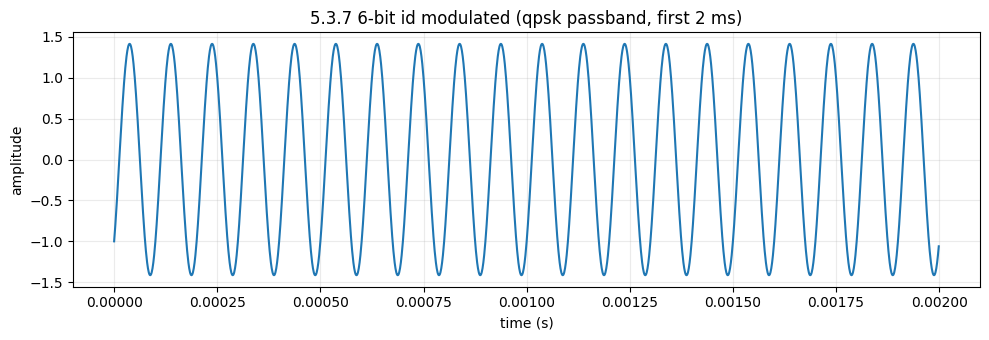

In [18]:

import numpy as np
import matplotlib.pyplot as plt

if "qpsk_tx" not in globals() or not callable(globals()["qpsk_tx"]):
    raise NameError("qpsk_tx not defined.")
if "mib" not in globals():
    raise NameError("mib not defined.")
if "corr_mib" not in globals() or "mib_pos_hat" not in globals():
    raise NameError("run 5.3.3 first (corr_mib, mib_pos_hat).")
if "zc_tx" not in globals():
    raise NameError("run 5.3.4 first (zc_tx).")
if "xc6" not in globals() or "t6" not in globals():
    raise NameError("run 5.3.6 first (t6, xc6).")
if "out" not in globals():
    raise NameError("out not defined.")

fs = float(out["params"]["fs"])
tb = float(out["params"]["tb"])
fc = float(out["params"]["fc"])
ns = int(round(fs * tb))

tm, xcm, tbbm, ybbm, symm = qpsk_tx(mib, fs=fs, tb=tb, fc=fc)

n_show = int(0.002 * fs)  # 2 ms window (2000 samples)
plt.figure(figsize=(10, 3.5))
plt.plot(tm[:n_show], xcm[:n_show])
plt.title("5.3.7 mib modulated signal (passband, first 2 ms)")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.8))
plt.plot(np.real(zc_tx), label="real")
plt.plot(np.imag(zc_tx), label="imag")
plt.title("5.3.7 transmitted zadoff-chu sequence (baseband)")
plt.xlabel("n")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10, 3.5))
plt.plot(corr_mib)
plt.axvline(mib_pos_hat, linestyle="--", linewidth=1.2)
plt.title("5.3.7 mib correlation output (valid)")
plt.xlabel("candidate bit position")
plt.ylabel("correlation")
plt.grid(True, alpha=0.25)
plt.tight_layout()

n_show = int(0.002 * fs)
plt.figure(figsize=(10, 3.5))
plt.plot(t6[:n_show], xc6[:n_show])
plt.title("5.3.7 6-bit id modulated (qpsk passband, first 2 ms)")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


plt.show()
